In [ ]:
pip install qiskit qiskit-machine-learning qiskit-aer

In [ ]:
pip install estimator


In [ ]:
!pip install --upgrade qiskit-machine-learning

In [ ]:
pip install qiskit qiskit-machine-learning qiskit-aer

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN

Loaded 912 samples | 13 features
Class balance — Confirmed: 584 | False Positive: 328

Training Classical CNN Baseline...
  Epoch   0 | Loss: 0.6850
  Epoch  10 | Loss: 0.6439
  Epoch  20 | Loss: 0.6172
  Epoch  30 | Loss: 0.5920
  Epoch  40 | Loss: 0.5635



  Classical CNN Baseline Results
  Accuracy    : 0.7486
  F1          : 0.8258
  Recall      : 0.9316
  Precision   : 0.7415

Building U-gate quantum circuit (5 qubits)...
Encoding 13 features → 5 quantum features
Each qubit uses U(θ,φ,λ) to encode 3 features simultaneously

Extracting quantum features via U-gate QNN...
Quantum features shape: (912, 5)

Training Hybrid U-gate QNN → CNN...
  Epoch   0 | Loss: 0.6771
  Epoch  10 | Loss: 0.6543
  Epoch  20 | Loss: 0.6504
  Epoch  30 | Loss: 0.6443
  Epoch  40 | Loss: 0.6424

  Hybrid U-gate QNN → CNN Results
  Accuracy    : 0.6393
  F1          : 0.7800
  Recall      : 1.0000
  Precision   : 0.6393

                                                       
  FINAL RESULTS
                                                       
  Metric         Classical CNN  Hybrid QNN-CNN
-------------------------------------------------------
  Accuracy              0.7486          0.6393  ↓ 0.1093
  F1                    0.8258          0.7800  ↓ 0.0458

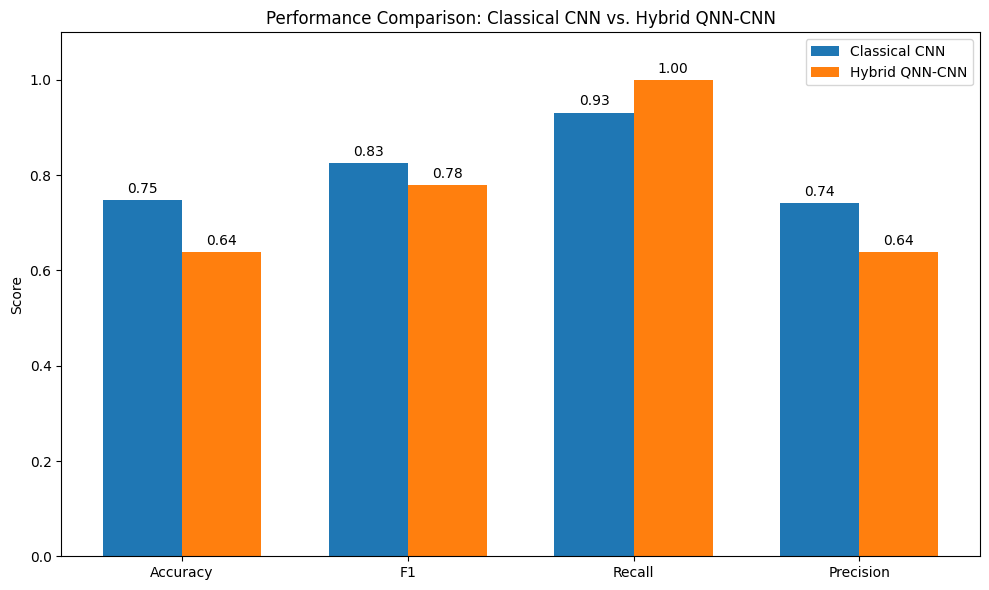

In [27]:
def load_data(path):
    """
    1 = CONFIRMED exoplanet, 0 = FALSE POSITIVE
    """
    df = pd.read_csv(path)
    features = [
        'koi_period', 'koi_time0bk', 'koi_impact',
        'koi_duration', 'koi_depth', 'koi_model_snr',
        'koi_prad', 'koi_teq', 'koi_insol',
        'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag'
    ]
    #Selecting features
    features = [f for f in features if f in df.columns]
    df = df[features + ['target']].dropna()

    X = df[features].values
    y = df['target'].values.astype(int)

    print(f"Loaded {X.shape[0]} samples | {X.shape[1]} features")
    print(f"Class balance — Confirmed: {y.sum()} | False Positive: {(y==0).sum()}")
    return X, y, features


def preprocess(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    angle_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_angles = angle_scaler.fit_transform(X_scaled)
    return X_angles, scaler, angle_scaler


# U-Gate Quantum Circuit (Feature Reduction)
def u_gate(num_input_features, num_qubits=5):
    """
    Encodes 3 features per qubit using U(theta, phi, lambda) gates.
    With 5 qubits:
      Each qubit gets 3 features via U gate angles
      Total features: num_qubits * 3 = 15
      """

    features_per_qubit= 3
    total_input_params= num_qubits *features_per_qubit
    actual_input= min(num_input_features, total_input_params)

    x = ParameterVector('x', actual_input)
    theta = ParameterVector('θ', num_qubits)

    qc = QuantumCircuit(num_qubits)

    #U gate encodes 3 features per qubit
    for i in range(num_qubits):
        idx = i * features_per_qubit

        f0 = x[idx % actual_input]
        f1 = x[(idx + 1) %actual_input]
        f2 = x[(idx + 2) %actual_input]
        qc.u(f0, f1, f2, i)

    #Entanglement layer
    for i in range(num_qubits-1):
        qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    for i in range(num_qubits):
        qc.ry(theta[i], i)

    return qc, x, theta


#Build QNN
def build_qnn(qc, x, theta, num_qubits=5):
    """
    Wraps the U-gate circuit in an EstimatorQNN.
    Measures PauliZ expectation value on each qubit.
    Output shape(n_samples, num_qubits), these are our reduced quantum features.
    """
    estimator = StatevectorEstimator()

    # One observable per qubit, Z measurement on each
    observables = [
        SparsePauliOp.from_list([
            ("I" * (num_qubits - 1 - i) + "Z" + "I" * i, 1)
        ])
        for i in range(num_qubits)
    ]

    qnn = EstimatorQNN(
        circuit=qc,
        observables=observables,
        input_params=list(x),
        weight_params=list(theta),
        estimator=estimator
    )
    return qnn


#Extract Quantum Features
def extract_quantum_features(qnn, X, batch_size=50):
    """
    Passes Kepler data through U-gate QNN.
    Returns reduced quantum features: shape (n_samples, num_qubits).
"""
    weights = np.random.rand(qnn.num_weights)
    output = qnn.forward(X, weights)
    return output


# Classical CNN Classifier
class CNN(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )


        with torch.no_grad():
            dummy = torch.randn(1, 1, input_dim)
            flat_size = self.conv(dummy).view(1, -1).size(1)

        self.fc = nn.Sequential(
            nn.Linear(flat_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# Train & Evaluate
def train_and_evaluate(X, y, label="Model", epochs=50):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    model = CNN(X.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"\nTraining {label}...")
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    # Evaluate
    model.eval()
    X_te = torch.tensor(X_test, dtype=torch.float32)
    with torch.no_grad():
        preds = (model(X_te).numpy() > 0.5).astype(int).flatten()

    results = {
        'Accuracy':  accuracy_score(y_test, preds),
        'F1':        f1_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'Precision': precision_score(y_test, preds, zero_division=0),
    }

    print(f"\n{'='*40}")
    print(f"  {label} Results")
    print(f"{'='*40}")
    for k, v in results.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"{'='*40}")

    return results

def print_comparison_results(results_classical, results_hybrid):
    # Final Comparison Table
    print(f"\n{'':<55}\n  FINAL RESULTS\n{'':<55}")
    print(f"  {'Metric':<12} {'Classical CNN':>15} {'Hybrid QNN-CNN':>15}")
    print("-"*55)
    for metric in ['Accuracy', 'F1', 'Recall', 'Precision']:
        c = results_classical[metric]
        h = results_hybrid[metric]
        diff = h - c
        arrow = "\u2191" if diff > 0 else "\u2193"
        print(f"  {metric:<12} {c:>15.4f} {h:>15.4f}  {arrow} {abs(diff):.4f}")
    print("\n")
    print("Does quantum feature reduction improve CNN performance?")

    rq_metrics = {
        'F1': results_hybrid['F1'] > results_classical['F1'],
        'Recall': results_hybrid['Recall'] > results_classical['Recall']
    }
    for metric_name, improved in rq_metrics.items():
        print(f"  {metric_name} improved:     {'YES \u2713' if improved else 'NO \u2717'}")


def main():
    path= "/content/Copy train_data - train_data.csv.csv"
    qubits= 5


    X, y, feature_names = load_data(path)
    X_angles, _, _ = preprocess(X)


    results_classical = train_and_evaluate(
        X_angles, y, label="Classical CNN Baseline"
    )

    # U-gate QNN feature reduction -> CNN
    print(f"\nBuilding U-gate quantum circuit ({qubits} qubits)...")
    print(f"Encoding {X.shape[1]} features \u2192 {qubits} quantum features")
    print("Each qubit uses U(\u03B8,\u03C6,\u03BB) to encode 3 features simultaneously\n")

    qc, x, theta = u_gate(X_angles.shape[1], qubits)
    qnn = build_qnn(qc, x, theta, qubits)

    print("Extracting quantum features via U-gate QNN...")
    X_quantum = extract_quantum_features(qnn, X_angles)
    print(f"Quantum features shape: {X_quantum.shape}")

    results_hybrid = train_and_evaluate(
        X_quantum, y, label="Hybrid U-gate QNN \u2192 CNN"
    )

    print_comparison_results(results_classical, results_hybrid)

    # Plotting Results
    import matplotlib.pyplot as plt
    metrics = ['Accuracy', 'F1', 'Recall', 'Precision']
    classical_values = [results_classical[m] for m in metrics]
    hybrid_values = [results_hybrid[m] for m in metrics]
    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, classical_values, width, label='Classical CNN')
    rects2 = ax.bar(x + width/2, hybrid_values, width, label='Hybrid QNN-CNN')
    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison: Classical CNN vs. Hybrid QNN-CNN')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, 1.1)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()